# Part C

# Imports

In [1]:
import os
import random
import copy
import torch
import pandas as pd
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import DataLoader, Subset, random_split, Dataset
from torchvision import datasets, transforms
from torchvision import models
from sklearn.metrics import confusion_matrix

# Pre Data Augmentation

[cats] cat.2763.jpg - Raw Size: (499, 375)
[cats] cat.7803.jpg - Raw Size: (499, 483)
[cats] cat.6134.jpg - Raw Size: (500, 373)
[cats] cat.3404.jpg - Raw Size: (499, 379)
[dogs] dog.3132.jpg - Raw Size: (432, 386)
[dogs] dog.5456.jpg - Raw Size: (450, 443)
[dogs] dog.78.jpg - Raw Size: (500, 374)
[dogs] dog.1476.jpg - Raw Size: (432, 321)


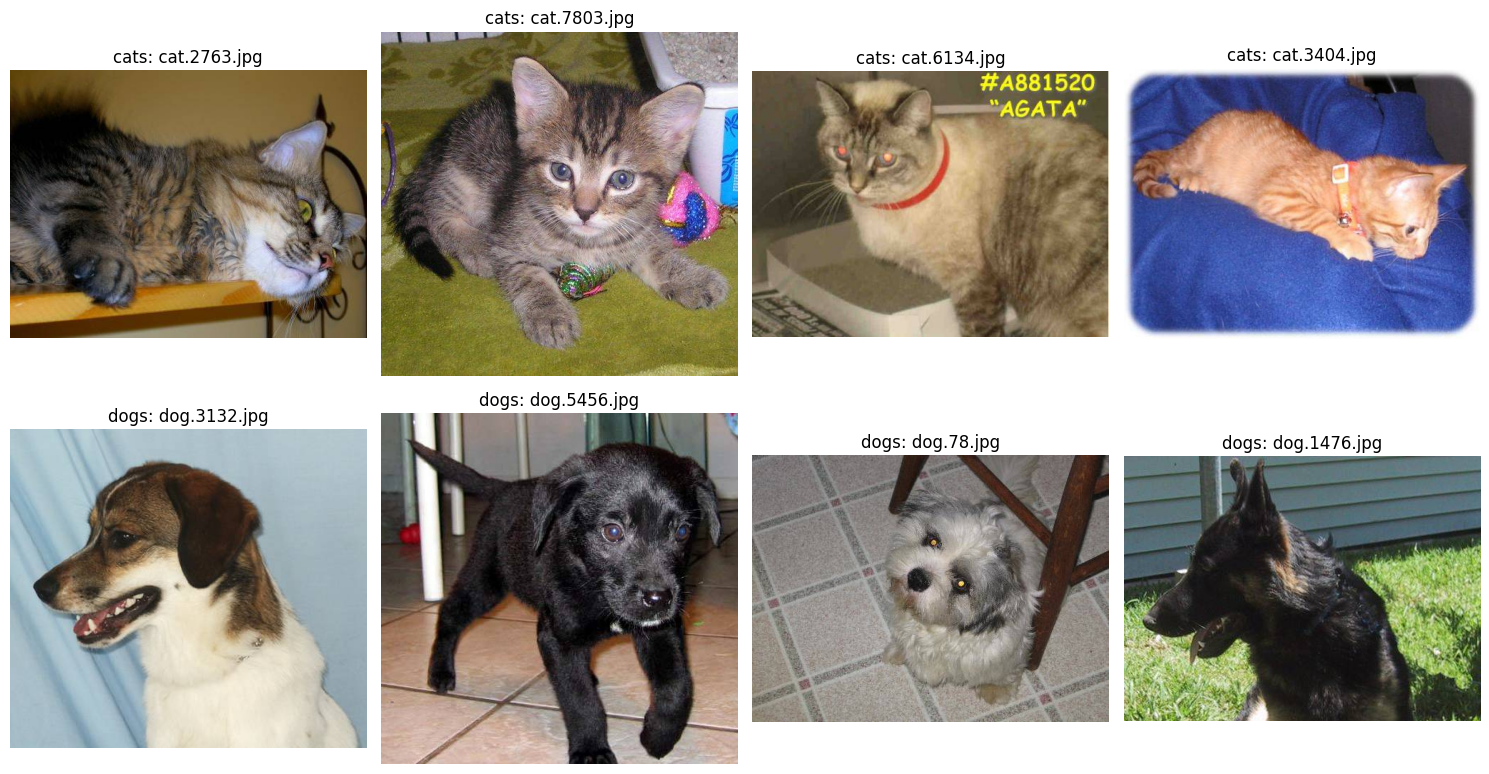

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data_path = 'ecse-415-winter-2026-dog-vs-cat-classification/train/train'

def show_random_samples(data_dir, num_samples=4):
    classes = ['cats', 'dogs']
    
    plt.figure(figsize=(15, 8))
    for i, clas in enumerate(classes):
        cls_dir = os.path.join(data_dir, clas)

        # file names
        images = [f for f in os.listdir(cls_dir) if f.endswith('.jpg')]
        
        # get a random sample
        samples = random.sample(images, num_samples)
        
        for j, img_name in enumerate(samples):
            img_path = os.path.join(cls_dir, img_name)
            img = Image.open(img_path)
            
            # 1, 2, 3, 4 for cats; 5, 6, 7, 8 for dogs
            plt.subplot(2, num_samples, i * num_samples + j + 1)
            plt.imshow(img)
            plt.title(f"{clas}: {img_name}")
            plt.axis('off')

            print(f"[{clas}] {img_name} - Raw Size: {img.size}")
            
    plt.tight_layout()
    plt.show()

show_random_samples(data_path)

In [3]:
cat_count = len(os.listdir(os.path.join(data_path, 'cats')))
dog_count = len(os.listdir(os.path.join(data_path, 'dogs')))

print(f"Cats: {cat_count}")
print(f"Dogs: {dog_count}")
print(f"Total: {cat_count + dog_count}")


Cats: 10021
Dogs: 9979
Total: 20000


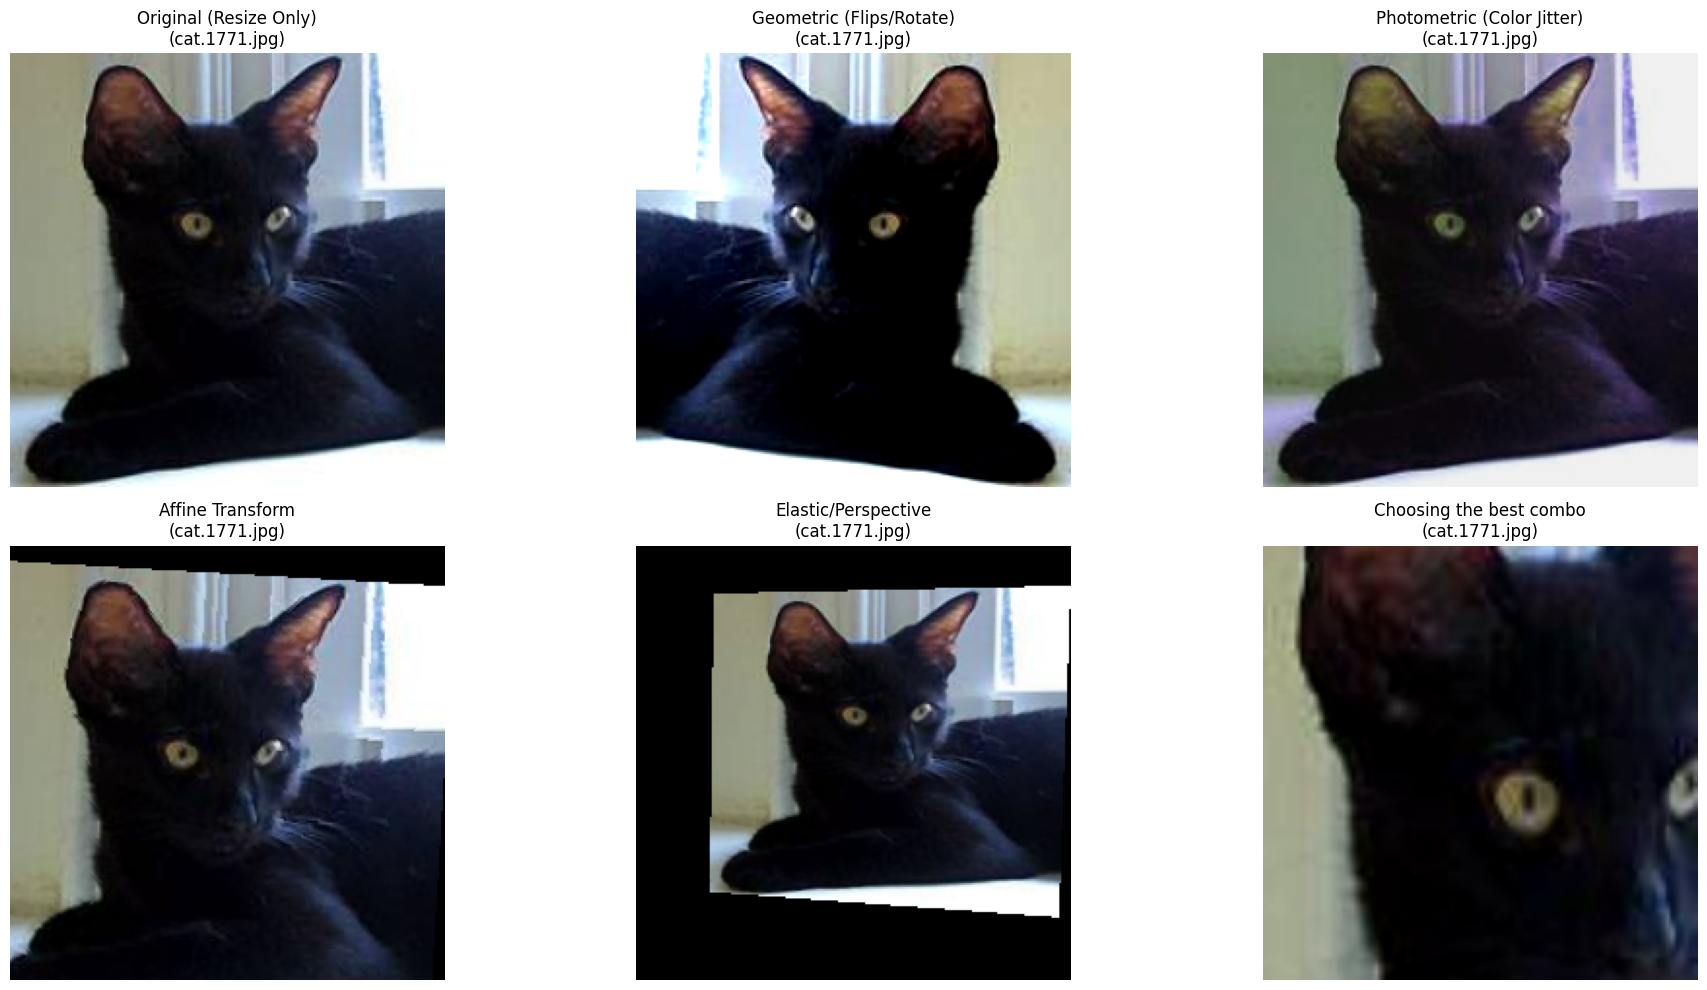

In [4]:
def get_random_img_pth(dir_path):
    cls = random.choice(['cats', 'dogs'])
    cls_dir = os.path.join(dir_path, cls)
    img_name = random.choice(os.listdir(cls_dir))
    return os.path.join(cls_dir, img_name)

# try different data augmentations and visualize the results and then pick the best one for training
augmentations = {
    "Original (Resize Only)": transforms.Compose([
        transforms.Resize((224, 224))
    ]),
    
    "Geometric (Flips/Rotate)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=1.0), # Forced on for visualization
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2)
    ]),
    
    "Photometric (Color Jitter)": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
    ]),
    
    "Affine Transform": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomAffine(degrees=30, translate=(0.1, 0.1), scale=(0.8, 1.2))
    ]),
    
    "Elastic/Perspective": transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomPerspective(distortion_scale=0.5, p=1.0)
    ]),
    
    "Choosing the best combo": transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.2, 0.2, 0.2)
    ])
}

img_path = get_random_img_pth(data_path)
img = Image.open(img_path).convert('RGB')

plt.figure(figsize=(20, 10))

for i, (name, policy) in enumerate(augmentations.items()):
    augmented_img = policy(img)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_img)
    plt.title(f"{name}\n({img_path.split(os.sep)[-1]})", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
# chosen transforms for training and validation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet normalization
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)), # resize a bit larger
    transforms.CenterCrop(224),    # crop the exact center
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# split 80/20
full_dataset = datasets.ImageFolder(data_path, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
seed = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=seed)

# blow up the pic to 256 first and then resize to 224 to match training set 
val_dataset.dataset = copy.copy(full_dataset)
val_dataset.dataset.transform = val_transform

# loading the data into dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Total train batches: {len(train_loader)}")
print(f"Total validation batches: {len(val_loader)}")


Total train batches: 500
Total validation batches: 125


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# use the pretrained ResNet-50 model and modify the final layer for only two classes
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# replace the final layer with our 2 classes (Cats vs Dogs)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2) 

model = model.to(device)
print("Model initialized and moved to:", device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 5
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}") # print current epoch

    model.train()
    running_loss = 0.0
    
    # start training loop
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

        if (i + 1) % 100 == 0:
             print(f"Processed batch {i+1}/{len(train_loader)}")

    
    # validation
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()
            
    print(f"Train Loss: {running_loss/len(train_loader):.4f},  Validation Accuracy: {100 * val_correct / val_size:.2f}%")

# save model weights
torch.save(model.state_dict(), 'resnet50_cats_dogs.pth')
print("Model saved as 'resnet50_cats_dogs.pth'")

Model initialized and moved to: cuda

Epoch 1/5
Processed batch 100/500
Processed batch 200/500
Processed batch 300/500
Processed batch 400/500
Processed batch 500/500
Train Loss: 0.1454,  Validation Accuracy: 98.90%

Epoch 2/5
Processed batch 100/500
Processed batch 200/500
Processed batch 300/500
Processed batch 400/500
Processed batch 500/500
Train Loss: 0.1157,  Validation Accuracy: 98.40%

Epoch 3/5
Processed batch 100/500
Processed batch 200/500
Processed batch 300/500
Processed batch 400/500
Processed batch 500/500
Train Loss: 0.1162,  Validation Accuracy: 98.55%

Epoch 4/5
Processed batch 100/500
Processed batch 200/500
Processed batch 300/500
Processed batch 400/500
Processed batch 500/500
Train Loss: 0.1010,  Validation Accuracy: 98.62%

Epoch 5/5
Processed batch 100/500
Processed batch 200/500
Processed batch 300/500
Processed batch 400/500
Processed batch 500/500
Train Loss: 0.0977,  Validation Accuracy: 98.20%
Model saved as 'resnet50_cats_dogs.pth'


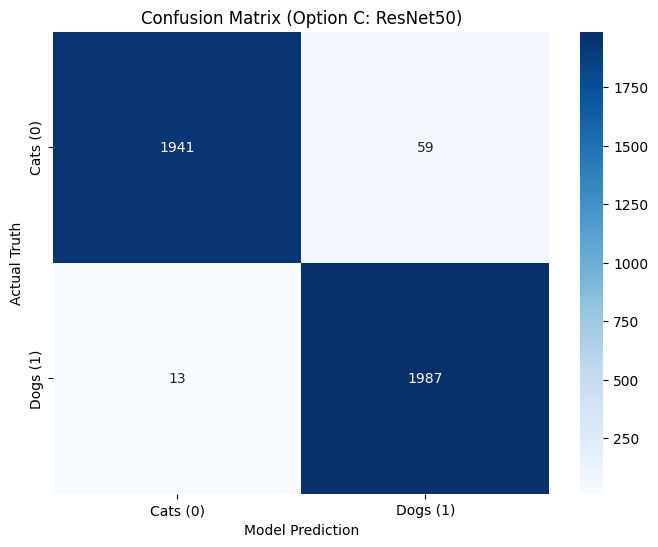

In [7]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        # put it back on CPU and convert to numpy for confusion matrix
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

confusion_mat = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Cats (0)', 'Dogs (1)'], 
            yticklabels=['Cats (0)', 'Dogs (1)'])
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.title(f'Confusion Matrix (Option C: ResNet50)')
plt.show()


In [8]:
# function to create a custom dataset for the Kaggle test set since it doesn't have labels and we need to return the ID for submission
class KaggleTestDataset(Dataset):
    def __init__(self, test_dir, transform=None):
        self.test_dir = test_dir
        self.image_files = [f for f in os.listdir(test_dir) if f.endswith('.jpg')]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.test_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        # return the image and its ID (without the .jpg extension) for submission
        image_id = img_name.split('.')[0] 
        return image, image_id

# setup the Test DataLoader
# use same val_tranform just like we did for validation set
test_dir = 'ecse-415-winter-2026-dog-vs-cat-classification/test/test'
test_dataset = KaggleTestDataset(test_dir, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# generate predictions
model.eval()
results = []

print("Testing on Kaggle Test Set:")
with torch.no_grad():
    for i, (images, image_ids) in enumerate(test_loader):
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        preds = predicted.cpu().numpy()
        for j in range(len(preds)):
            results.append({
                'id': image_ids[j],
                'label': preds[j]
            })

        if (i + 1) % 10 == 0:
            print(f"Processed {i+1}/{len(test_loader)} test batches")

# save to CSV
df_submission = pd.DataFrame(results)

df_submission['id'] = pd.to_numeric(df_submission['id'])
df_submission = df_submission.sort_values('id')
df_submission.to_csv('resnet50_kaggle_submission.csv', index=False)

print("Done. \nSaved 'resnet50_kaggle_submission.csv'.")

Testing on Kaggle Test Set:
Processed 10/157 test batches
Processed 20/157 test batches
Processed 30/157 test batches
Processed 40/157 test batches
Processed 50/157 test batches
Processed 60/157 test batches
Processed 70/157 test batches
Processed 80/157 test batches
Processed 90/157 test batches
Processed 100/157 test batches
Processed 110/157 test batches
Processed 120/157 test batches
Processed 130/157 test batches
Processed 140/157 test batches
Processed 150/157 test batches
Done. 
Saved 'resnet50_kaggle_submission.csv'.
